# NB01 — Data Cleaning
## Urdu Code-Switch Emotion Detector

**Purpose:** Load raw dataset -> inspect -> clean text -> remove duplicates -> analyse class distribution -> split into train/val/test -> save.

**Dataset:** Roman Urdu-English Code-Switched Emotion Dataset (20,000 rows)

**Output:** `train.csv`, `val.csv`, `test.csv` in `data/processed/`

---
## Step 1 — Import Libraries

In [15]:
# -- Data manipulation --
import pandas as pd
import numpy as np

# -- Visualisation --
import matplotlib.pyplot as plt
import seaborn as sns

# -- Text preprocessing --
import re
import warnings
warnings.filterwarnings('ignore')

# -- Splitting --
from sklearn.model_selection import train_test_split

# -- Path management --
from pathlib import Path

# -- Reproducibility --
RANDOM_STATE = 42

# -- Paths --
RAW_PATH       = Path("../data/raw/")
PROCESSED_PATH = Path("../data/processed/")
FIGURES_PATH   = Path("../outputs/figures/")

PROCESSED_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print("Libraries loaded OK")

Libraries loaded OK


---
## Step 2 — Load Data

In [17]:
# Load Excel file
df_raw = pd.read_excel("data/raw/RU_EN_Emotion_Dataset.xlsx")

print("Raw file loaded:")
print(f"  Shape: {df_raw.shape}")
print(f"  Columns: {df_raw.columns.tolist()}")

# Show first 3 rows to understand structure
print("First 3 rows (before processing):")
display(df_raw.head(3))

Raw file loaded:
  Shape: (20000, 4)
  Columns: ['Unnamed: 0', 'Tweets', 'Level 1', 'Level 2']
First 3 rows (before processing):


,Unnamed: 0,Tweets,Level 1,Level 2
0,0,yeh fair game nai thi I don’t like it,emotion,Anger
1,1,Nasir mama ban gya aur jija ji hinduo ko bol r...,emotion,Anger
2,2,: Part - #MissionMuzaffarabad #MasterShifujisM...,emotion,Anger


In [18]:
# Drop index column and rename
df = df_raw.drop(columns=['Unnamed: 0'])
df = df.rename(columns={'Tweets': 'text'})

# Map two-level labels to single label column
# Level 1 = "no emotion" -> neutral
# Level 1 = "emotion" + Level 2 -> specific emotion (lowercased)
print("Label mapping:")
print(f"  Level 1 values: {df['Level 1'].unique()}")
print(f"  Level 2 values: {sorted(df['Level 2'].unique())}")

df['label'] = df['Level 2'].str.strip().str.lower()

# Drop original label columns
df = df.drop(columns=['Level 1', 'Level 2'])

print("After processing:")
print(f"  Shape: {df.shape}")
print(f"  Columns: {df.columns.tolist()}")
print(f"  Unique labels: {sorted(df['label'].unique())}")

Label mapping:
  Level 1 values: ['emotion' 'no emotion']
  Level 2 values: ['Anger', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
After processing:
  Shape: (20000, 2)
  Columns: ['text', 'label']
  Unique labels: ['anger', 'fear', 'happy', 'neutral', 'sad', 'surprise']


---
## Step 3 — Data Inspection

In [19]:
# -- 1. Shape --
print("=" * 50)
print("1. SHAPE")
print("=" * 50)
print(df.shape)

1. SHAPE
(20000, 2)


In [20]:
# -- 2. Column names + dtypes --
print("" + "=" * 50)
print("2. COLUMN NAMES AND DATA TYPES")
print("=" * 50)
df.info()

2. COLUMN NAMES AND DATA TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    19999 non-null  object
 1   label   20000 non-null  object
dtypes: object(2)
memory usage: 312.6+ KB


In [21]:
# -- 3. Missing values --
print("" + "=" * 50)
print("3. MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())
print(f"Total missing values: {df.isnull().sum().sum()}")

3. MISSING VALUES
text     1
label    0
dtype: int64
Total missing values: 1


In [22]:
# -- 4. Duplicate rows --
print("" + "=" * 50)
print("4. DUPLICATE ROWS")
print("=" * 50)
print(f"Exact duplicate rows: {df.duplicated().sum()}")

4. DUPLICATE ROWS
Exact duplicate rows: 273


In [23]:
# -- 5. Random sample --
print("" + "=" * 50)
print("5. FIVE RANDOM SAMPLES")
print("=" * 50)
display(df.sample(5, random_state=RANDOM_STATE))

5. FIVE RANDOM SAMPLES


,text,label
10650,Salam.. I Am From RWP mre pas lt0 dead pra hua...,neutral
2041,Main nay PTi ko vote dia aur aj tak hr mamalay...,anger
8668,Am your big fan maim.....you r legend.....kya ...,neutral
1114,Law enforcing institutions are sleeping. Where...,anger
13902,Bhai Mujhy Pata laga tha ke un ko Aik lack waz...,neutral


In [24]:
# -- 6. Statistical description --
print("" + "=" * 50)
print("6. STATISTICAL DESCRIPTION")
print("=" * 50)
display(df.describe(include='all'))

6. STATISTICAL DESCRIPTION


,text,label
count,19999,20000
unique,19535,6
top,"Please do something, coz of family entire soci...",neutral
freq,6,11629


In [25]:
# -- 7. Label distribution --
print("" + "=" * 50)
print("7. LABEL DISTRIBUTION")
print("=" * 50)
label_counts = df['label'].value_counts()
print(label_counts)
print(f"Imbalance ratio (max/min): {label_counts.max() / label_counts.min():.1f}x")

7. LABEL DISTRIBUTION
label
neutral     11629
happy        3720
anger        3487
sad           712
fear          228
surprise      224
Name: count, dtype: int64
Imbalance ratio (max/min): 51.9x


---
## Step 4 — Key Observations

**Dataset size**
- Total rows: 20,000 (from single Excel file)
- Columns: `text` (object), `label` (object)

**Missing values**
- 1 missing value found in `text` column — will be dropped in cleaning

**Duplicate records**
- [Run inspection to fill in] exact duplicate rows found — will be removed after text cleaning

**Label distribution**

| Label    | Count  | % of total |
|----------|--------|------------|
| neutral  | 11,629 | 58.1%      |
| happy    | 3,720  | 18.6%      |
| anger    | 3,487  | 17.4%      |
| sad      | 712    | 3.6%       |
| fear     | 228    | 1.1%       |
| surprise | 224    | 1.1%       |

**Imbalance ratio:** 52x (neutral vs surprise/fear)

**Severe class imbalance** — fear and surprise are extremely rare. Will use weighted loss in NB03.

**Text patterns observed**
- Mix of Roman Urdu and English tokens (code-switched)
- Emojis present — will be preserved
- URLs and @mentions likely present
- Some offensive/political content (expected for anger class)

**Cleaning plan**
1. Drop 1 null row in `text` column
2. Apply `clean_text()`: remove URLs, @mentions, HTML tags, excess whitespace
3. Remove exact duplicates (on cleaned text)
4. Preserve emojis and non-ASCII characters (critical for Urdu)
5. No lowercasing (Roman Urdu has no case)
6. Stratified split to ensure rare classes in all sets

---
## Step 5 — Data Cleaning

### 5a. Drop missing values

In [26]:
before_null = len(df)
df = df.dropna(subset=['text']).reset_index(drop=True)
after_null = len(df)

print(f"Rows with null text dropped: {before_null - after_null}")
print(f"Rows remaining: {after_null:,}")

Rows with null text dropped: 1
Rows remaining: 19,999


### 5b. Define text cleaning function

In [29]:
def clean_text(text: str) -> str:
    """
    Clean social media text for code-switched NLP.

    REMOVES:   URLs, @mentions, HTML tags, excess whitespace
    PRESERVES: emojis, Urdu/Arabic characters, all non-ASCII, hashtag words
    DOES NOT:  lowercase, remove punctuation, normalise Roman Urdu spelling
    """
    text = str(text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # URLs
    text = re.sub(r'@\w+', '', text)                    # mentions
    text = re.sub(r'<[^>]+>', '', text)                 # HTML tags
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()            # collapse whitespace
    return text

print("clean_text() defined")

clean_text() defined


### 5c. Test function on 5 examples

In [30]:
print("Before/after examples:")
print("-" * 80)
for i in range(5):
    raw     = df['text'].iloc[i]
    cleaned = clean_text(raw)
    print(f"BEFORE: {raw}")
    print(f"AFTER:  {cleaned}")
    print()

Before/after examples:
--------------------------------------------------------------------------------
BEFORE: yeh fair game nai thi I don’t like it
AFTER:  yeh fair game nai thi I don’t like it

BEFORE: Nasir mama ban gya aur jija ji hinduo ko bol rha h.... Abe katue teri kom me sab aise hi Najayaz aate h kya....ek ke pass v kagaz nhi h...sab suar sale Halala ki Najayaz Paidaish hi hai
AFTER:  Nasir mama ban gya aur jija ji hinduo ko bol rha h.... Abe katue teri kom me sab aise hi Najayaz aate h kya....ek ke pass v kagaz nhi h...sab suar sale Halala ki Najayaz Paidaish hi hai

BEFORE: : Part - #MissionMuzaffarabad #MasterShifujisMissionMuzaffarabad Mujhe Acre confirm Khareedna Hai Muzaffarabad me. J
AFTER:  : Part - MissionMuzaffarabad MasterShifujisMissionMuzaffarabad Mujhe Acre confirm Khareedna Hai Muzaffarabad me. J

BEFORE: O bhai ghoor se daikho vehicle parking ki wjah se rush hua para hai, ankhain kholo aur daikho, think before you tweet
AFTER:  O bhai ghoor se daikho vehicle 

### 5d. Apply cleaning function

In [31]:
# Apply to full dataset
text_clean_series = df['text'].apply(clean_text)

# Confirm no nulls introduced
assert text_clean_series.isnull().sum() == 0, "Nulls introduced by clean_text()"

# Assign to DataFrame
df['text_clean'] = text_clean_series
print(f"clean_text() applied to {len(df):,} rows")

clean_text() applied to 19,999 rows


---
## Step 6 — Remove Duplicates

In [32]:
before = len(df)
df = df.drop_duplicates(subset='text_clean').reset_index(drop=True)
after  = len(df)

print(f"Duplicates removed : {before - after}")
print(f"Rows before        : {before:,}")
print(f"Rows after         : {after:,}")
print(f"Reduction          : {(before - after) / before * 100:.1f}%")

Duplicates removed : 464
Rows before        : 19,999
Rows after         : 19,535
Reduction          : 2.3%


---
## Step 7 — Class Distribution Analysis

### 7a. Print class statistics

In [34]:
counts = df['label'].value_counts()
ratio  = counts.max() / counts.min()

print("Class counts:")
print(counts.to_string())
print(f"Imbalance ratio (max/min): {ratio:.1f}x")

if ratio > 5:
    print("Warning: Significant imbalance — use weighted loss in NB03")

Class counts:
label
neutral     11370
happy        3656
anger        3408
sad           672
fear          222
surprise      207
Imbalance ratio (max/min): 54.9x


### 7b. Visualise distribution

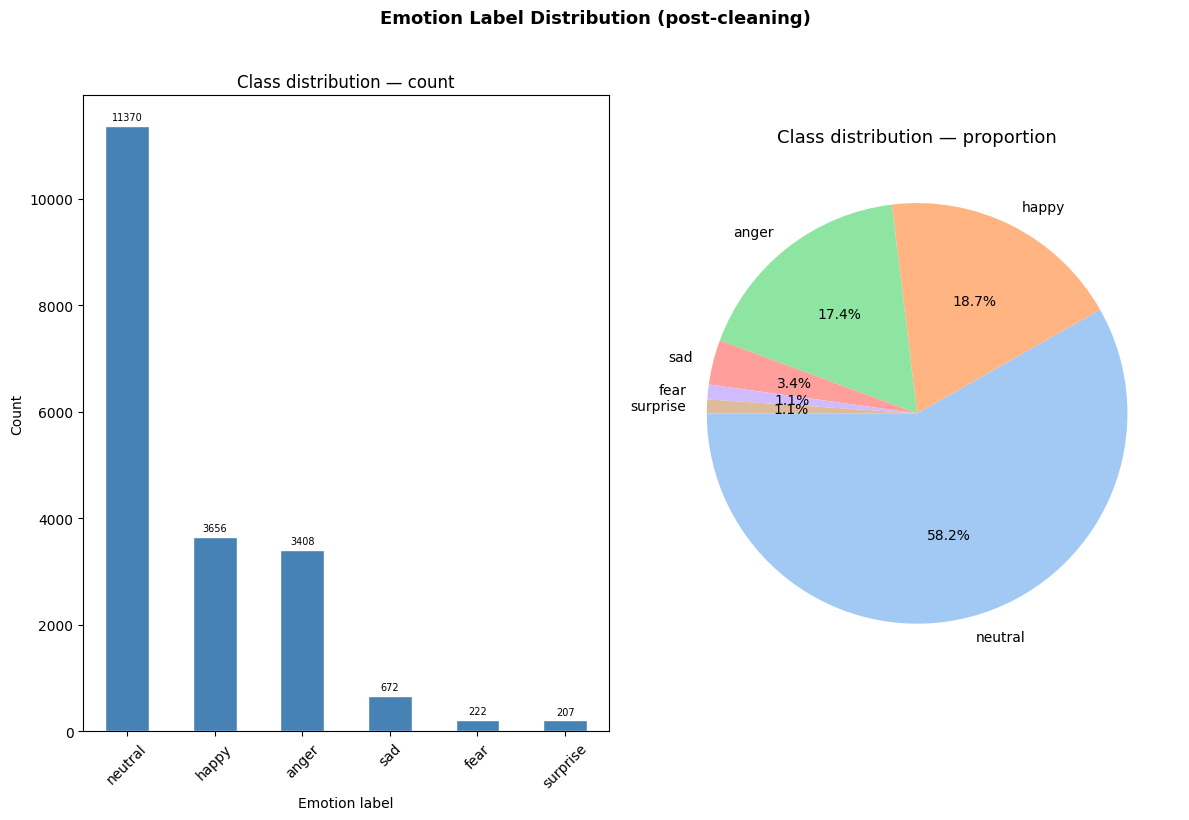

Saved -> ../outputs/figures/class_distribution.png


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

# Bar chart
counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Class distribution — count', fontsize=12)
axes[0].set_xlabel('Emotion label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts):
    axes[0].text(i, v + 100, str(v), ha='center', fontsize=7)

# Pie chart
counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=180,
            colors=sns.color_palette('pastel'))
axes[1].set_title('Class distribution — proportion', fontsize=13)
axes[1].set_ylabel('')

plt.suptitle('Emotion Label Distribution (post-cleaning)', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()

save_path = FIGURES_PATH / 'class_distribution.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {save_path}")

---
## Step 8 — Train / Val / Test Split

**CRITICAL:** This split must happen before any further analysis to prevent data leakage.

In [51]:
# Stage 1: train (70%) vs temp (30%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df['label']
)

# Stage 2: val (15%) vs test (15%) — split temp 50/50
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df['label']
)

print(f"Split complete:")
print(f"  Train : {len(train_df):>6,} rows  ({len(train_df)/len(df)*100:.0f}%)")
print(f"  Val   : {len(val_df):>6,} rows  ({len(val_df)/len(df)*100:.0f}%)")
print(f"  Test  : {len(test_df):>6,} rows  ({len(test_df)/len(df)*100:.0f}%)")

Split complete:
  Train : 13,674 rows  (70%)
  Val   :  2,930 rows  (15%)
  Test  :  2,931 rows  (15%)


---
## Step 9 — Verify Split Quality

In [56]:
print(f"{'Label':<12} {'Full%':>7} {'Train%':>8} {'Val%':>7} {'Test%':>7}")
print("-" * 48)

for label in sorted(df['label'].unique()):
    full_p  = (df['label']       == label).mean() * 100
    train_p = (train_df['label'] == label).mean() * 100
    val_p   = (val_df['label']   == label).mean() * 100
    test_p  = (test_df['label']  == label).mean() * 100
    print(f"{label:<12} {full_p:>6.1f}%  {train_p:>6.1f}% {val_p:>6.1f}%  {test_p:>6.1f}%")

print("All splits match if each row's values are within ~1% of Full%")

Label          Full%   Train%    Val%   Test%
------------------------------------------------
anger          17.4%    17.4%   17.4%    17.4%
fear            1.1%     1.1%    1.2%     1.1%
happy          18.7%    18.7%   18.7%    18.7%
neutral        58.2%    58.2%   58.2%    58.2%
sad             3.4%     3.4%    3.4%     3.4%
surprise        1.1%     1.1%    1.1%     1.1%
All splits match if each row's values are within ~1% of Full%


---
## Step 10 — Save Processed Datasets

In [57]:
train_df.to_csv(PROCESSED_PATH / 'train.csv', index=False)
val_df.to_csv(PROCESSED_PATH   / 'val.csv',   index=False)
test_df.to_csv(PROCESSED_PATH  / 'test.csv',  index=False)

print("Datasets saved:")
print(f"  {PROCESSED_PATH / 'train.csv'}  — {len(train_df):,} rows")
print(f"  {PROCESSED_PATH / 'val.csv'}    — {len(val_df):,} rows")
print(f"  {PROCESSED_PATH / 'test.csv'}   — {len(test_df):,} rows")
print(f"  Columns: {list(train_df.columns)}")

Datasets saved:
  ../data/processed/train.csv  — 13,674 rows
  ../data/processed/val.csv    — 2,930 rows
  ../data/processed/test.csv   — 2,931 rows
  Columns: ['text', 'label', 'text_clean']


---
## Notebook Summary

| Step | Action | Result |
|---|---|---|
| Load | Loaded single Excel file | 20,000 rows |
| Inspect | 7 checks completed | See Key Observations above |
| Clean | Dropped 1 null, removed URLs/mentions/HTML | Emojis + Urdu preserved |
| Dedup | Removed exact duplicates on cleaned text | [Check output above] rows removed |
| Split | Stratified 70/15/15 | Train / Val / Test |
| Save | Written to data/processed/ | 3 CSV files |

**Class imbalance:** 52x ratio (neutral vs surprise/fear) -> use weighted loss in NB03

**Next notebook:** `NB02_eda.ipynb`  
Use `train.csv` only for all analysis. Val and test are now locked.